In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from xgboost.callback import EarlyStopping
from imblearn.over_sampling import SMOTE

In [3]:
pwd

'/mnt/Windows/Users/ashto/Disk/Projects/BoxOfficeAI/backend/notebooks'

In [4]:
df = pd.read_csv('../../data/movies.csv', low_memory=False)
credits = pd.read_csv('../../data/credits.csv')

print("Movies:", df.shape)
print("Credits:", credits.shape)

Movies: (45466, 24)
Credits: (45476, 3)


In [5]:
df["id"] = pd.to_numeric(df["id"], errors="coerce")
credits["id"] = pd.to_numeric(credits["id"], errors="coerce")

df = df.merge(credits, on="id")

print("After merge:", df.shape)

After merge: (45538, 26)


In [6]:
df.dtypes

adult                        str
belongs_to_collection        str
budget                       str
genres                       str
homepage                     str
id                       float64
imdb_id                      str
original_language            str
original_title               str
overview                     str
popularity                   str
poster_path                  str
production_companies         str
production_countries         str
release_date                 str
revenue                  float64
runtime                  float64
spoken_languages             str
status                       str
tagline                      str
title                        str
video                     object
vote_average             float64
vote_count               float64
cast                         str
crew                         str
dtype: object

In [7]:
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["gross"] = pd.to_numeric(df["revenue"], errors="coerce")

df = df.dropna(subset=["gross"])

df["budget"] = df["budget"].replace(0, np.nan)
df["budget"] = df["budget"].fillna(df["budget"].median())

print("After cleaning:", df.shape)

After cleaning: (45535, 27)


In [8]:
def get_genre(x):
    try:
        genres = ast.literal_eval(x)
        return genres[0]["name"] if genres else "Unknown"
    except:
        return "Unknown"

df["genre"] = df["genres"].apply(get_genre)

df["year"] = pd.to_datetime(df["release_date"], errors='coerce').dt.year
df["score"] = df["vote_average"]
df["votes"] = df["vote_count"]

df = df.dropna(subset=["year", "score"])

In [9]:
def get_director(x):
    try:
        crew = ast.literal_eval(x)
        for member in crew:
            if member["job"] == "Director":
                return member["name"]
        return "Unknown"
    except:
        return "Unknown"

def get_main_actor(x):
    try:
        cast = ast.literal_eval(x)
        return cast[0]["name"] if len(cast) > 0 else "Unknown"
    except:
        return "Unknown"

df["director"] = df["crew"].apply(get_director)
df["main_actor"] = df["cast"].apply(get_main_actor)

In [10]:
df = df.sort_values(by="year")

In [11]:
df["log_budget"] = np.log1p(df["budget"])
df["log_gross"] = np.log1p(df["gross"])

df["log_votes"] = np.log1p(df["votes"])

df["budget_runtime"] = df["budget"] / (df["runtime"] + 1)
df["log_runtime"] = np.log1p(df["runtime"])
df["budget_year"] = df["budget"] * df["year"]

In [12]:
df = df.sort_values(by="year") 

df["director_power"] = (
    df.groupby("director")["log_gross"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

df["actor_power"] = (
    df.groupby("main_actor")["log_gross"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

In [13]:
median_gross = df["gross"].median()

df["director_power"] = df["director_power"].fillna(median_gross)
df["actor_power"] = df["actor_power"].fillna(median_gross)
df["log_director_power"] = np.log1p(df["director_power"])
df["log_actor_power"] = np.log1p(df["actor_power"])

In [14]:
threshold = df["gross"].quantile(0.7)
df["hit"] = (df["gross"] > threshold).astype(int)

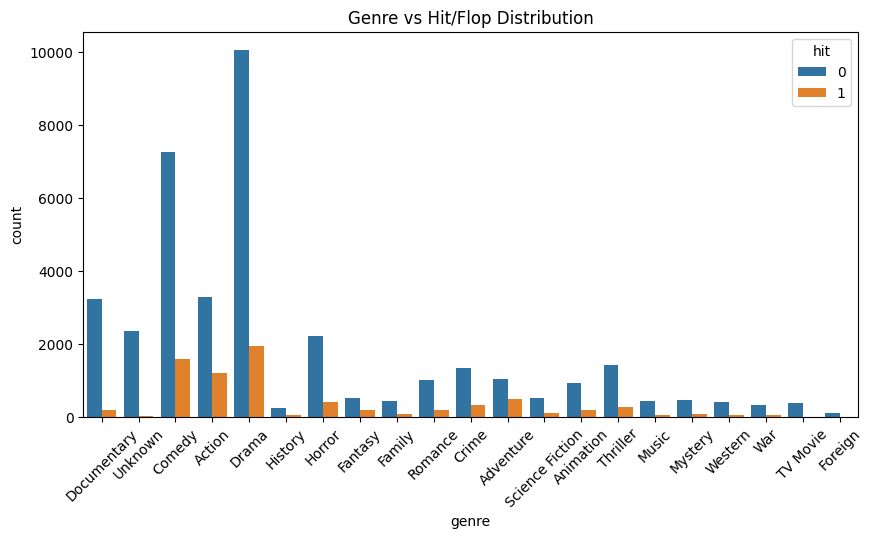

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="genre", hue="hit")
plt.title("Genre vs Hit/Flop Distribution")
plt.xticks(rotation=45)
plt.show()

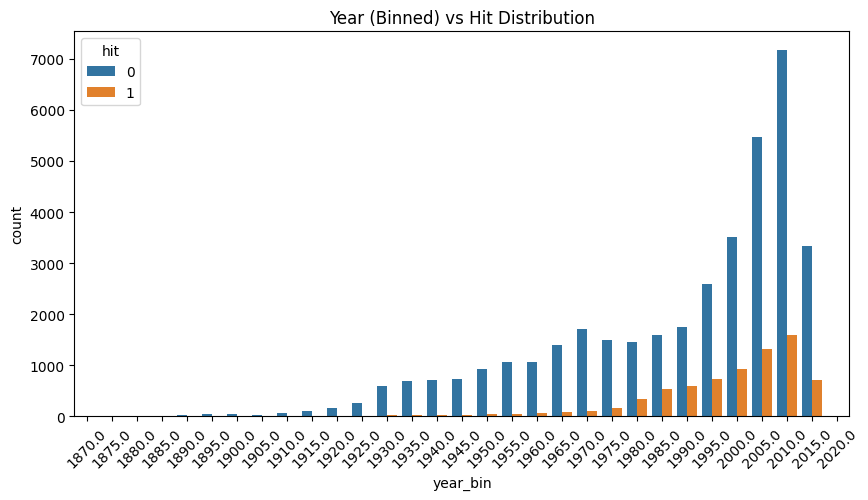

In [16]:
df["year_bin"] = (df["year"] // 5) * 5

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="year_bin", hue="hit")
plt.title("Year (Binned) vs Hit Distribution")
plt.xticks(rotation=45)
plt.show()

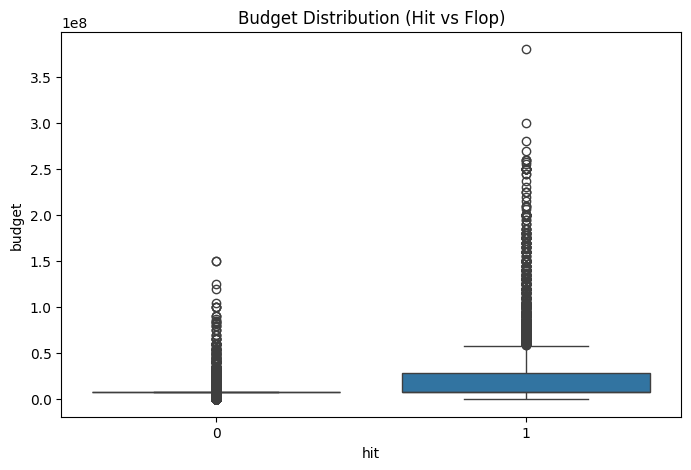

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="hit", y="budget")
plt.title("Budget Distribution (Hit vs Flop)")
plt.show()

In [18]:
le = LabelEncoder()
df["genre"] = le.fit_transform(df["genre"].astype(str))

In [19]:
df.isnull().sum()

adult                        0
belongs_to_collection    40954
budget                       0
genres                       0
homepage                 37672
id                           0
imdb_id                     14
original_language           11
original_title               0
overview                   941
popularity                   0
poster_path                339
production_companies         0
production_countries         0
release_date                 0
revenue                      0
runtime                    246
spoken_languages             0
status                      80
tagline                  25026
title                        0
video                        0
vote_average                 0
vote_count                   0
cast                         0
crew                         0
gross                        0
genre                        0
year                         0
score                        0
votes                        0
director                     0
main_act

<Axes: xlabel='hit', ylabel='count'>

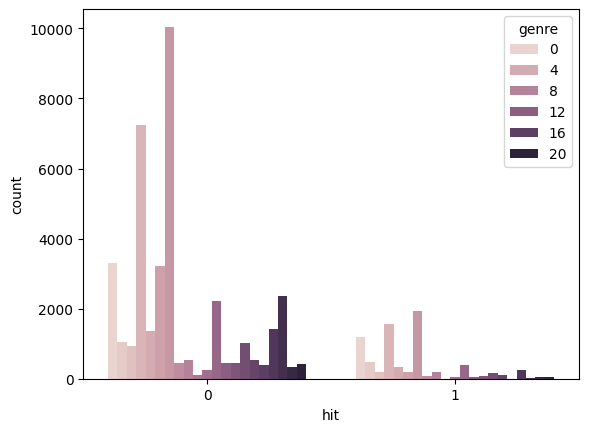

In [20]:
sns.countplot(data=df, x="hit", hue="genre")

<Axes: xlabel='budget'>

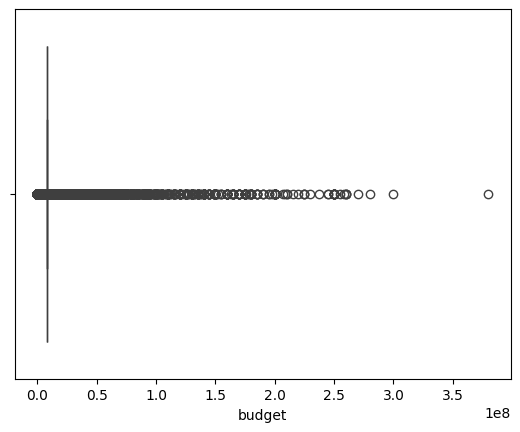

In [21]:
sns.boxplot(data=df, x="budget")

<Axes: xlabel='votes'>

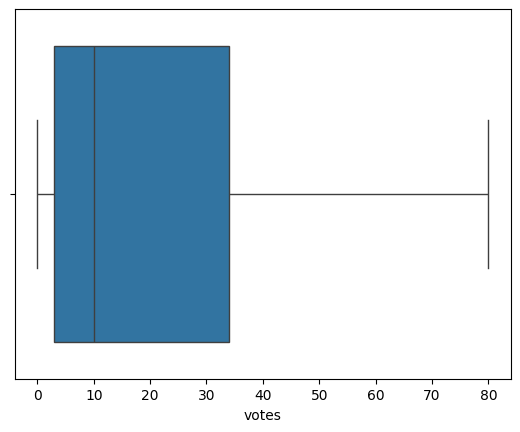

In [22]:
sns.boxplot(data=df, x="votes", showfliers=False)

<Axes: xlabel='runtime'>

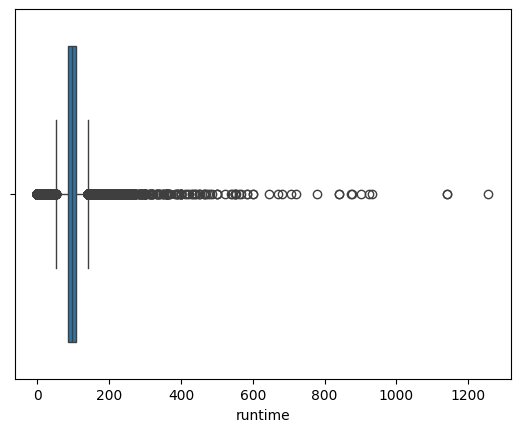

In [23]:
sns.boxplot(data=df, x="runtime")

<Axes: xlabel='director_power'>

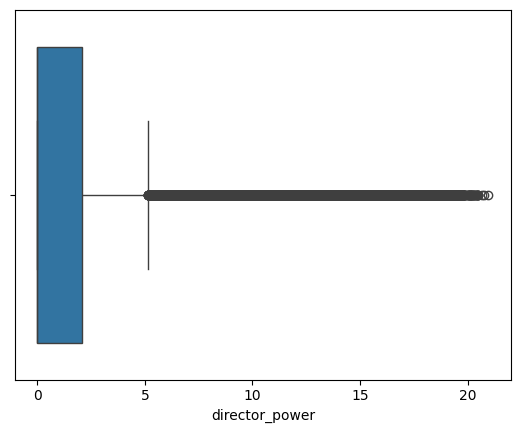

In [24]:
sns.boxplot(data=df, x="director_power")

<Axes: xlabel='actor_power'>

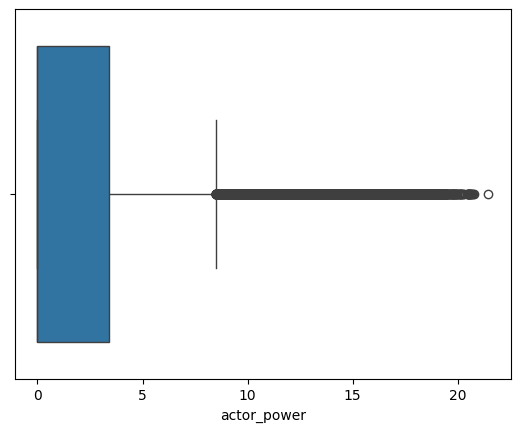

In [25]:
sns.boxplot(data=df, x="actor_power")

In [26]:
df_clean = df.copy()

cols = ["budget", "runtime", "votes"]
df_clean[cols] = df_clean[cols].fillna(df_clean[cols].median())
z = np.abs(stats.zscore(df_clean[cols]))
before = df_clean.shape[0]
df_clean = df_clean[(z < 3).all(axis=1)]
after = df_clean.shape[0]
df = df_clean

print("OUTLIER REMOVAL IMPACT")
print("="*40)
print(f"Before rows : {before}")
print(f"After rows  : {after}")
print(f"Removed rows: {before - after}")
print(f"Data kept   : {(after/before)*100:.2f}%")

OUTLIER REMOVAL IMPACT
Before rows : 45451
After rows  : 43912
Removed rows: 1539
Data kept   : 96.61%


<Axes: >

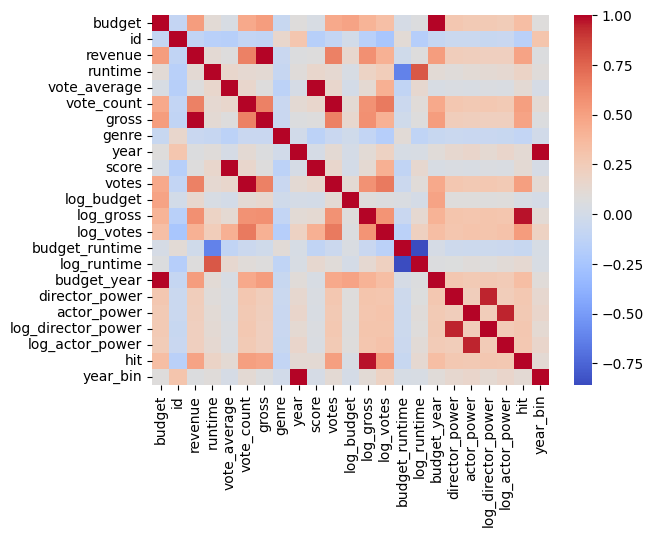

In [50]:
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, fmt=".2g", cmap="coolwarm")

In [27]:
features = [
    "genre",
    "year",
    "runtime",
    "log_runtime",
    "log_budget",
    "budget_runtime",
    "budget_year",
    "log_director_power",
    "log_actor_power",
    "log_votes"
]

df = df.fillna(0)

X = df[features]
y_reg = df["log_gross"]
y_cls = df["hit"]

print("Features used:", features)

Features used: ['genre', 'year', 'runtime', 'log_runtime', 'log_budget', 'budget_runtime', 'budget_year', 'log_director_power', 'log_actor_power', 'log_votes']


In [28]:
y_cls.value_counts(normalize=True)

hit
0    0.858194
1    0.141806
Name: proportion, dtype: float64

In [29]:
X_train_cls, X_test_cls, y_cls_train, y_cls_test = train_test_split(
    X, y_cls, test_size=0.2, stratify=y_cls, random_state=42
)

In [30]:
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [34]:
scaler_cls = StandardScaler()

X_train_cls = scaler_cls.fit_transform(X_train_cls)
X_test_cls = scaler_cls.transform(X_test_cls)

smote = SMOTE(random_state=42)
X_train_cls, y_cls_train = smote.fit_resample(X_train_cls, y_cls_train)

In [35]:
y_cls_train.value_counts()

hit
0    30147
1    30147
Name: count, dtype: int64

In [36]:
scaler_reg = StandardScaler()

X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

In [37]:
reg_models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
}

# Classification models
clf_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
}

In [38]:
results = []

print("🚀 Training Regression Models...\n")

# Regression
for name, model in reg_models.items():
    print(f"🔹 {name}")
    
    model.fit(X_train_reg, y_reg_train)
    y_pred = model.predict(X_test_reg)
    
    mse = mean_squared_error(y_reg_test, y_pred)
    mae = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reg_test, y_pred)
    
    results.append({
        "Model": name,
        "Task": "Regression",
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1": None
    })


print("\n🚀 Training Classification Models...\n")

# Classification
for name, model in clf_models.items():
    print(f"🔹 {name}")
    
    model.fit(X_train_cls, y_cls_train)
    
    # use probability threshold for all
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_cls)[:, 1]
        y_pred = (probs > 0.4).astype(int)
    else:
        y_pred = model.predict(X_test_cls)
    
    acc = accuracy_score(y_cls_test, y_pred)
    precision = precision_score(y_cls_test, y_pred)
    recall = recall_score(y_cls_test, y_pred)
    f1 = f1_score(y_cls_test, y_pred)
    
    results.append({
        "Model": name,
        "Task": "Classification",
        "MSE": None,
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

print("\n✅ Done!")

🚀 Training Regression Models...

🔹 Linear Regression
🔹 Decision Tree
🔹 Random Forest
🔹 Gradient Boosting
🔹 XGBoost


/home/subtilizer/miniconda/envs/ml/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [09:44:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



🚀 Training Classification Models...

🔹 Decision Tree
🔹 Random Forest
🔹 Gradient Boosting
🔹 XGBoost

✅ Done!


In [39]:
results_df = pd.DataFrame(results)

# Regression Table
reg_table = results_df[results_df["Task"] == "Regression"][
    ["Model", "MSE", "MAE", "RMSE", "R2"]
].copy()

reg_table = reg_table.sort_values(by="R2", ascending=False).round(4)


# Classification Table
clf_table = results_df[results_df["Task"] == "Classification"][
    ["Model", "Accuracy", "Precision", "Recall", "F1"]
].copy()

clf_table["Accuracy"] = clf_table["Accuracy"].apply(
    lambda x: f"{x*100:.2f}%" if pd.notnull(x) else None
)

clf_table = clf_table.sort_values(by="F1", ascending=False).round(4)


# Display both
from IPython.display import display

print("\n📊 REGRESSION RESULTS")
display(reg_table)

print("\n📊 CLASSIFICATION RESULTS")
display(clf_table)


📊 REGRESSION RESULTS


,Model,MSE,MAE,RMSE,R2
3,Gradient Boosting,14.2718,1.9463,3.7778,0.5276
2,Random Forest,14.4138,1.8597,3.7966,0.5229
4,XGBoost,15.2661,1.8996,3.9072,0.4947
1,Decision Tree,15.7376,1.8907,3.9671,0.4791
0,Linear Regression,18.7696,2.9737,4.3324,0.3787



📊 CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1
8,XGBoost,89.99%,0.6285,0.7189,0.6707
7,Gradient Boosting,86.64%,0.5184,0.8137,0.6333
6,Random Forest,84.39%,0.4719,0.8498,0.6068
5,Decision Tree,83.18%,0.4493,0.8257,0.5819


In [40]:
best_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

best_reg.fit(X_train_reg, y_reg_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [41]:
xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    device='cuda',
    random_state=42
)

xgb_clf.fit(X_train_cls, y_cls_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [42]:
y_pred_reg = best_reg.predict(X_test_reg)
y_pred_reg = np.expm1(y_pred_reg)
y_reg_test_actual = np.expm1(y_reg_test)

mse = mean_squared_error(y_reg_test_actual, y_pred_reg)
mae = mean_absolute_error(y_reg_test_actual, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test_actual, y_pred_reg)

print("🔹 REGRESSION (Gradient Boosting)")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

🔹 REGRESSION (Gradient Boosting)
MSE  : 321214011365092.2500
MAE  : 3518369.1266
RMSE : 17922444.3468
R²   : 0.2736


In [43]:
probs = xgb_clf.predict_proba(X_test_cls)[:, 1]
y_pred_cls = (probs > 0.4).astype(int)

precision = precision_score(y_cls_test, y_pred_cls)
recall = recall_score(y_cls_test, y_pred_cls)
f1 = f1_score(y_cls_test, y_pred_cls)
accuracy = accuracy_score(y_cls_test, y_pred_cls)

print("\nCLASSIFICATION")
print(f"Accuracy Score  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


CLASSIFICATION
Accuracy Score  : 89.99%
Precision : 0.6285
Recall    : 0.7189
F1 Score  : 0.6707


In [44]:
print("\nFINAL RESULTS")
print("="*40)

print("\nRegression:")
print(f"MSE  : {format(mse)}")
print(f"MAE  : {format(mae)}")
print(f"RMSE : {format(rmse)}")
print(f"R²   : {format(r2)}")

print("\nClassification:")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


FINAL RESULTS

Regression:
MSE  : 321214011365092.25
MAE  : 3518369.126605558
RMSE : 17922444.346826475
R²   : 0.273642960247239

Classification:
Accuracy  : 89.99%
Precision : 0.6285
Recall    : 0.7189
F1 Score  : 0.6707


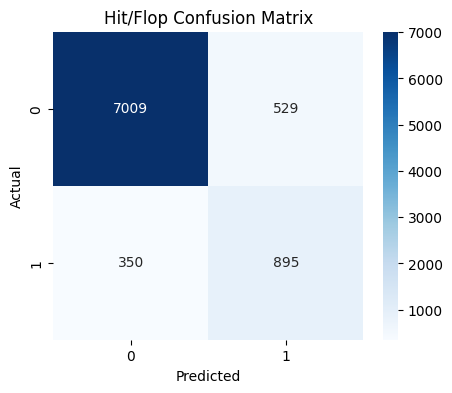

In [45]:
cm = confusion_matrix(y_cls_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hit/Flop Confusion Matrix")
plt.show()

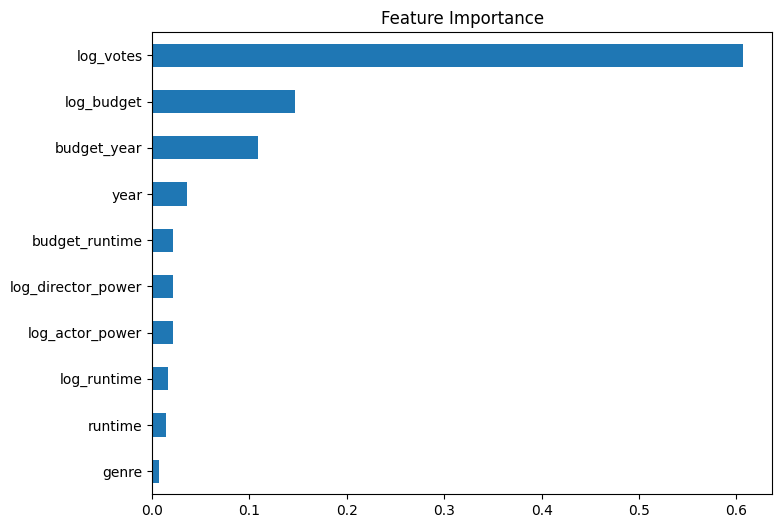

In [46]:
importance = pd.Series(best_reg.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [47]:

import os
import joblib

os.makedirs("../model", exist_ok=True)

# save best models
joblib.dump(best_reg, "../model/regressor.pkl")
joblib.dump(xgb_clf, "../model/classifier.pkl")
joblib.dump(scaler_reg, "../model/scaler_reg.pkl")
joblib.dump(scaler_cls, "../model/scaler_cls.pkl")
joblib.dump(le, "../model/genre_encoder.pkl")

print("✅ Best models saved in ../model/")

✅ Best models saved in ../model/
